In [3]:
# ===============================
# 1️⃣ Setup
# ===============================

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random

print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
# ==================================
# 2️⃣ Graph Generation
# ==================================

def generate_path_graph(n):
    return nx.path_graph(n)

def generate_complete_graph(n):
    return nx.complete_graph(n)

def generate_tree_graph(r, h):
    return nx.balanced_tree(r, h)

def generate_small_world(n, k, p):
    return nx.watts_strogatz_graph(n, k, p)


In [5]:
# ==================================
# Graph Visualization
# ==================================

def draw_graph(G, title):
    plt.figure(figsize=(6,6))
    nx.draw(G, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.title(title)
    plt.show()


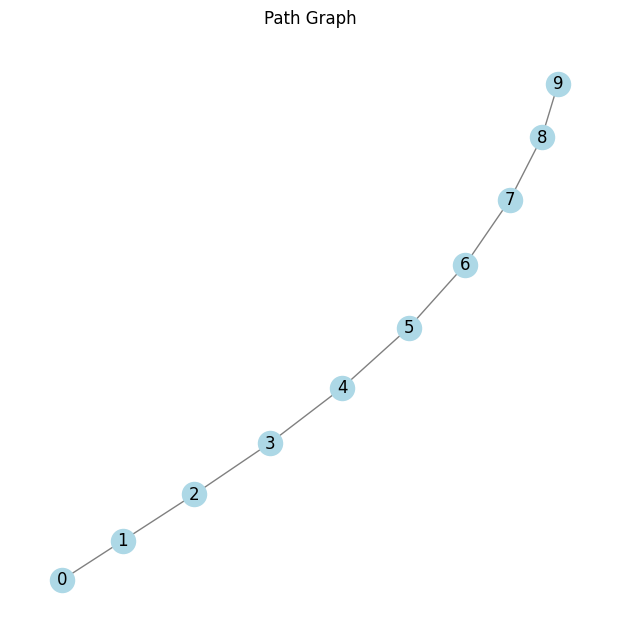

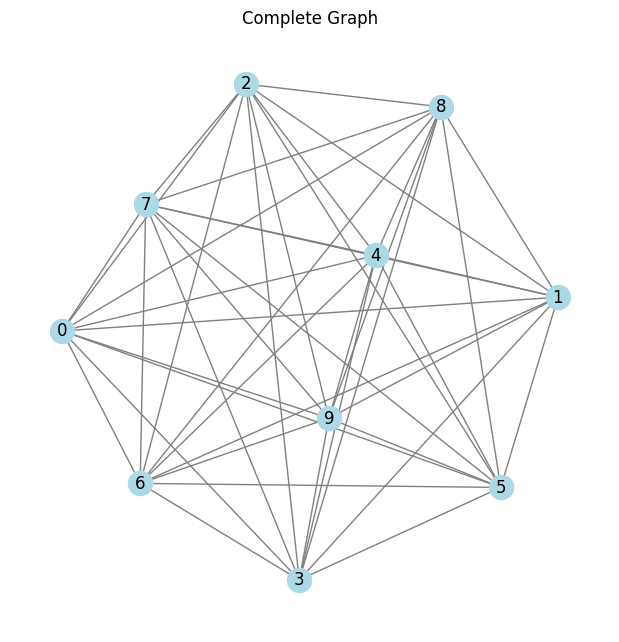

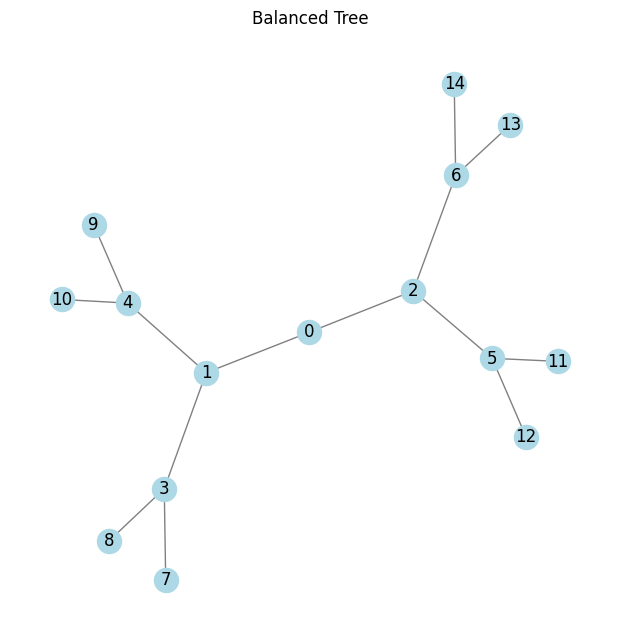

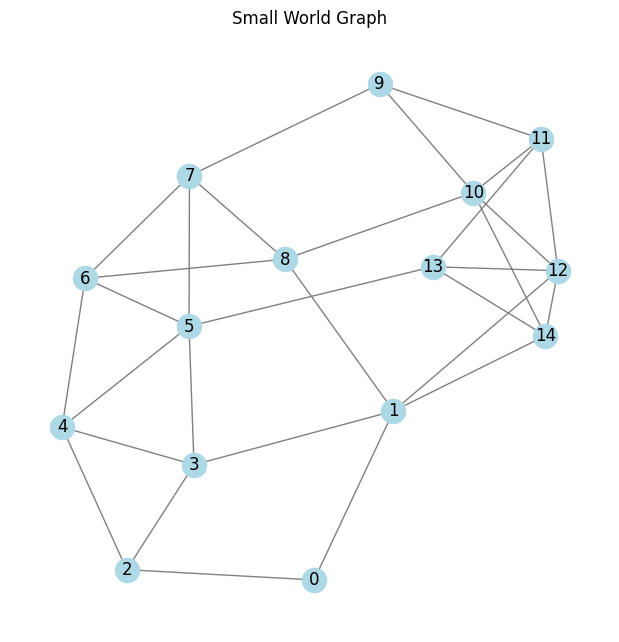

In [7]:
# ==================================
# Generate Sample Graphs
# ==================================

G1 = generate_path_graph(10)
draw_graph(G1, "Path Graph")

G2 = generate_complete_graph(10)
draw_graph(G2, "Complete Graph")

G3 = generate_tree_graph(2, 3)
draw_graph(G3, "Balanced Tree")

G4 = generate_small_world(15, 4, 0.2)
draw_graph(G4, "Small World Graph")


In [11]:
# ==================================
# 3️⃣ Attribute Assignment
# ==================================

def initialize_states(G):
    for node in G.nodes():
        G.nodes[node]['state'] = 0  # all start correct

def assign_roles_advanced(G):
    centrality = nx.degree_centrality(G)
    
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    
    n = len(G.nodes())
    
    for i, (node, _) in enumerate(sorted_nodes):
        if i < 0.1 * n:
            G.nodes[node]['role'] = 'Leader'
        elif i < 0.3 * n:
            G.nodes[node]['role'] = 'Reviewer'
        else:
            G.nodes[node]['role'] = 'Worker'



In [12]:
# ==================================
# Apply Attributes Example
# ==================================

initialize_states(G4)
# assign_roles(G4)
assign_roles_advanced(G4)

for node in G4.nodes(data=True):
    print(node)


(0, {'role': 'Worker', 'state': 0})
(1, {'role': 'Leader', 'state': 0})
(2, {'role': 'Worker', 'state': 0})
(3, {'role': 'Reviewer', 'state': 0})
(4, {'role': 'Worker', 'state': 0})
(5, {'role': 'Leader', 'state': 0})
(6, {'role': 'Worker', 'state': 0})
(7, {'role': 'Worker', 'state': 0})
(8, {'role': 'Worker', 'state': 0})
(9, {'role': 'Worker', 'state': 0})
(10, {'role': 'Reviewer', 'state': 0})
(11, {'role': 'Worker', 'state': 0})
(12, {'role': 'Reviewer', 'state': 0})
(13, {'role': 'Worker', 'state': 0})
(14, {'role': 'Worker', 'state': 0})


In [13]:
# ==================================
# 4️⃣ Fault Injection - Random
# ==================================

def inject_random_faults(G, k):
    """
    Randomly select k nodes and mark them as faulty (state = 1)
    """
    nodes = list(G.nodes())
    faulty_nodes = random.sample(nodes, k)
    
    for node in faulty_nodes:
        G.nodes[node]['state'] = 1
    
    return faulty_nodes


In [14]:
# ==================================
# 4️⃣ Fault Injection - High Impact
# ==================================

def inject_targeted_faults(G, k):
    """
    Select top-k highest centrality nodes as faulty
    """
    centrality = nx.degree_centrality(G)
    
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    
    faulty_nodes = [node for node, _ in sorted_nodes[:k]]
    
    for node in faulty_nodes:
        G.nodes[node]['state'] = 1
    
    return faulty_nodes


In [15]:
# ==================================
# 5️⃣ Independent Cascade Model
# ==================================

def propagate_independent_cascade(G, p):
    """
    One propagation step using probability p
    """
    new_states = {}
    
    for node in G.nodes():
        if G.nodes[node]['state'] == 1:  # faulty node
            for neighbor in G.neighbors(node):
                if G.nodes[neighbor]['state'] == 0:
                    if random.random() < p:
                        new_states[neighbor] = 1
    
    # apply updates
    for node in new_states:
        G.nodes[node]['state'] = 1


In [16]:
# ==================================
# Manager 50% Rule
# ==================================

def apply_manager_rule(G):
    """
    If a Leader receives >50% faulty inputs, it becomes faulty
    """
    new_faults = []
    
    for node in G.nodes():
        if G.nodes[node]['role'] == 'Leader':
            neighbors = list(G.neighbors(node))
            if len(neighbors) == 0:
                continue
            
            faulty_count = sum(G.nodes[n]['state'] for n in neighbors)
            
            if faulty_count / len(neighbors) > 0.5:
                new_faults.append(node)
    
    for node in new_faults:
        G.nodes[node]['state'] = 1


In [17]:
# ==================================
# Trust Weight Assignment
# ==================================

def assign_trust_weights(G):
    for u, v in G.edges():
        G[u][v]['trust'] = random.uniform(0.3, 1.0)

        
def propagate_trust_model(G, threshold):
    new_faults = []
    
    for node in G.nodes():
        if G.nodes[node]['state'] == 0:
            neighbors = list(G.neighbors(node))
            
            total_trust = 0
            
            for neighbor in neighbors:
                if G.nodes[neighbor]['state'] == 1:
                    total_trust += G[node][neighbor]['trust']
            
            if total_trust > threshold:
                new_faults.append(node)
    
    for node in new_faults:
        G.nodes[node]['state'] = 1


In [18]:
# ==================================
# 6️⃣ Simulation Loop
# ==================================

def run_simulation(G, steps=10, p=0.3, model="IC"):
    
    history = []
    
    for t in range(steps):
        
        if model == "IC":
            propagate_independent_cascade(G, p)
            apply_manager_rule(G)
        
        elif model == "TRUST":
            propagate_trust_model(G, threshold=1.5)
        
        # record stats
        faulty_count = sum(G.nodes[n]['state'] for n in G.nodes())
        history.append(faulty_count)
    
    return history


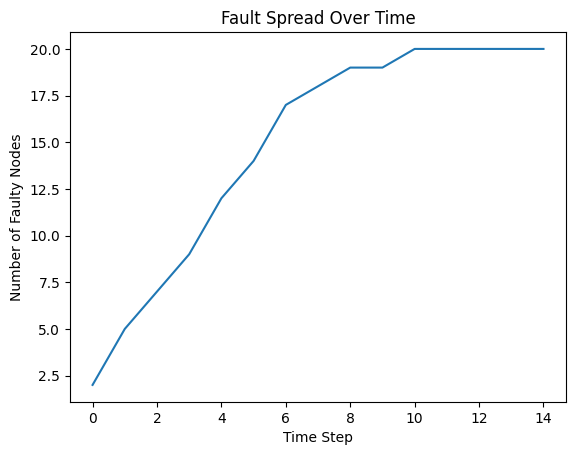

In [19]:
# Reset graph
G_test = generate_small_world(20, 4, 0.2)
initialize_states(G_test)
assign_roles_advanced(G_test)
assign_trust_weights(G_test)

inject_random_faults(G_test, k=2)

history = run_simulation(G_test, steps=15, p=0.3, model="IC")

plt.plot(history)
plt.xlabel("Time Step")
plt.ylabel("Number of Faulty Nodes")
plt.title("Fault Spread Over Time")
plt.show()
